In [ ]:
# -*- coding: utf-8 -*-
"""
VAE_CIFAR10_v2.ipynb (체크포인트 저장 추가)

변경사항:
- Google Drive에 모델 저장 → 세션 끊겨도 사전학습 보존
- Epoch 단축 (50 / 50) - plateau 확인 후 줄임
- 저장된 모델 있으면 자동 로드 → 사전학습 스킵 가능
"""

In [1]:
# Cell 1: Google Drive 마운트 (체크포인트 저장용)
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/vae_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'vae_pretrained.pth')
print(f"Checkpoint 경로: {CHECKPOINT_PATH}")

Mounted at /content/drive
Checkpoint 경로: /content/drive/MyDrive/vae_checkpoints/vae_pretrained.pth


In [2]:
# ============================================
# Cell 2: CIFAR-10 데이터셋
# ============================================
import torch
import torchvision
import torchvision.transforms as tr
from torch.utils.data import DataLoader

transf = tr.Compose([tr.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transf)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transf)

batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:03<00:00, 47.8MB/s]


In [3]:
# ============================================
# Cell 3: VAE 모델 정의 (이전과 동일)
# ============================================
import torch.nn as nn
import torch.nn.functional as F


class CIFAR10_VAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_logvar = nn.Linear(1024, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 1024)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 256, 2, 2)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [4]:
# ============================================
# Cell 4: 1단계 - VAE 사전학습 (저장된 모델 있으면 스킵)
# ============================================
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

vae_model = CIFAR10_VAE(latent_dim=256).to(device)
pretrain_loss_history = []

# 🔥 저장된 모델 있으면 로드, 없으면 학습
if os.path.exists(CHECKPOINT_PATH):
    print("✅ 저장된 사전학습 모델 발견! 로드합니다.")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    vae_model.load_state_dict(checkpoint['model_state_dict'])
    pretrain_loss_history = checkpoint['loss_history']
    print(f"   - 마지막 epoch loss: {pretrain_loss_history[-1]:.2f}")
else:
    print("📚 사전학습 시작...")
    optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)
    pretrain_epochs = 50  # plateau 확인 후 단축

    for epoch in range(pretrain_epochs):
        vae_model.train()
        running_loss, running_recon, running_kl = 0.0, 0.0, 0.0
        for images, _ in trainloader:
            images = images.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = vae_model(images)
            loss, recon_loss, kl_loss = vae_loss(recon, images, mu, logvar, beta=1.0)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_loss.item()

        avg_loss = running_loss / len(trainloader)
        avg_recon = running_recon / len(trainloader)
        avg_kl = running_kl / len(trainloader)
        pretrain_loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{pretrain_epochs}], "
              f"Total: {avg_loss:.2f} | Recon: {avg_recon:.2f} | KL: {avg_kl:.2f}")

        # 🔥 10 epoch마다 중간 저장 (안전장치)
        if (epoch + 1) % 10 == 0:
            torch.save({
                'model_state_dict': vae_model.state_dict(),
                'loss_history': pretrain_loss_history,
                'epoch': epoch + 1
            }, CHECKPOINT_PATH)
            print(f"   💾 중간 저장 완료 (epoch {epoch+1})")

    # 🔥 최종 저장
    torch.save({
        'model_state_dict': vae_model.state_dict(),
        'loss_history': pretrain_loss_history,
        'epoch': pretrain_epochs
    }, CHECKPOINT_PATH)
    print(f"✅ 사전학습 완료 & 저장: {CHECKPOINT_PATH}")

Device: cuda
📚 사전학습 시작...
Epoch [1/50], Total: 1900.14 | Recon: 1870.69 | KL: 29.45
Epoch [2/50], Total: 1848.71 | Recon: 1816.62 | KL: 32.09
Epoch [3/50], Total: 1841.30 | Recon: 1807.56 | KL: 33.74
Epoch [4/50], Total: 1836.88 | Recon: 1802.06 | KL: 34.82
Epoch [5/50], Total: 1834.48 | Recon: 1798.91 | KL: 35.57
Epoch [6/50], Total: 1831.96 | Recon: 1795.58 | KL: 36.38
Epoch [7/50], Total: 1830.30 | Recon: 1793.16 | KL: 37.15
Epoch [8/50], Total: 1828.96 | Recon: 1791.33 | KL: 37.63
Epoch [9/50], Total: 1827.87 | Recon: 1789.68 | KL: 38.19
Epoch [10/50], Total: 1827.10 | Recon: 1788.61 | KL: 38.49
   💾 중간 저장 완료 (epoch 10)
Epoch [11/50], Total: 1826.37 | Recon: 1787.73 | KL: 38.64
Epoch [12/50], Total: 1825.77 | Recon: 1786.93 | KL: 38.84
Epoch [13/50], Total: 1824.92 | Recon: 1785.87 | KL: 39.05
Epoch [14/50], Total: 1824.54 | Recon: 1785.24 | KL: 39.30
Epoch [15/50], Total: 1823.87 | Recon: 1784.41 | KL: 39.46
Epoch [16/50], Total: 1823.38 | Recon: 1783.75 | KL: 39.62
Epoch [17/50],

In [5]:
# ============================================
# Cell 5: 2단계 - Linear Probing
# ============================================
for param in vae_model.parameters():
    param.requires_grad = False


class VAELinearProbingModel(nn.Module):
    def __init__(self, pretrained_vae, latent_dim=256, num_classes=10):
        super().__init__()
        self.pretrained_vae = pretrained_vae
        self.pretrained_vae.eval()
        self.classifier = nn.Linear(latent_dim, num_classes)

    def train(self, mode=True):
        super().train(mode)
        self.pretrained_vae.eval()
        return self

    def forward(self, x):
        with torch.no_grad():
            mu, _ = self.pretrained_vae.encode(x)
        return self.classifier(mu)


probing_model = VAELinearProbingModel(vae_model, latent_dim=256).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(probing_model.classifier.parameters(), lr=1e-3)

probe_epochs = 50  # 충분 (이전 결과에서 50 근처면 수렴)
probe_loss_history = []

print("\n--- 2단계: 선형 분류기 학습 시작 ---")
for epoch in range(probe_epochs):
    probing_model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = probing_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    probe_loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{probe_epochs}], Loss: {avg_loss:.4f}")


--- 2단계: 선형 분류기 학습 시작 ---
Epoch [1/50], Loss: 1.9926
Epoch [2/50], Loss: 1.8168
Epoch [3/50], Loss: 1.7905
Epoch [4/50], Loss: 1.7817
Epoch [5/50], Loss: 1.7768
Epoch [6/50], Loss: 1.7734
Epoch [7/50], Loss: 1.7702
Epoch [8/50], Loss: 1.7679
Epoch [9/50], Loss: 1.7647
Epoch [10/50], Loss: 1.7623
Epoch [11/50], Loss: 1.7599
Epoch [12/50], Loss: 1.7575
Epoch [13/50], Loss: 1.7555
Epoch [14/50], Loss: 1.7535
Epoch [15/50], Loss: 1.7509
Epoch [16/50], Loss: 1.7498
Epoch [17/50], Loss: 1.7472
Epoch [18/50], Loss: 1.7452
Epoch [19/50], Loss: 1.7432
Epoch [20/50], Loss: 1.7413
Epoch [21/50], Loss: 1.7396
Epoch [22/50], Loss: 1.7373
Epoch [23/50], Loss: 1.7360
Epoch [24/50], Loss: 1.7342
Epoch [25/50], Loss: 1.7323
Epoch [26/50], Loss: 1.7310
Epoch [27/50], Loss: 1.7297
Epoch [28/50], Loss: 1.7287
Epoch [29/50], Loss: 1.7263
Epoch [30/50], Loss: 1.7244
Epoch [31/50], Loss: 1.7236
Epoch [32/50], Loss: 1.7215
Epoch [33/50], Loss: 1.7207
Epoch [34/50], Loss: 1.7190
Epoch [35/50], Loss: 1.7177
Ep

In [6]:
# ============================================
# Cell 6: 3단계 - 분류 정확도 측정
# ============================================
print("\n--- 3단계: 성능 평가 ---")
probing_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = probing_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"VAE Linear Probing 최종 분류 정확도: {accuracy:.2f}%")


--- 3단계: 성능 평가 ---
VAE Linear Probing 최종 분류 정확도: 41.16%


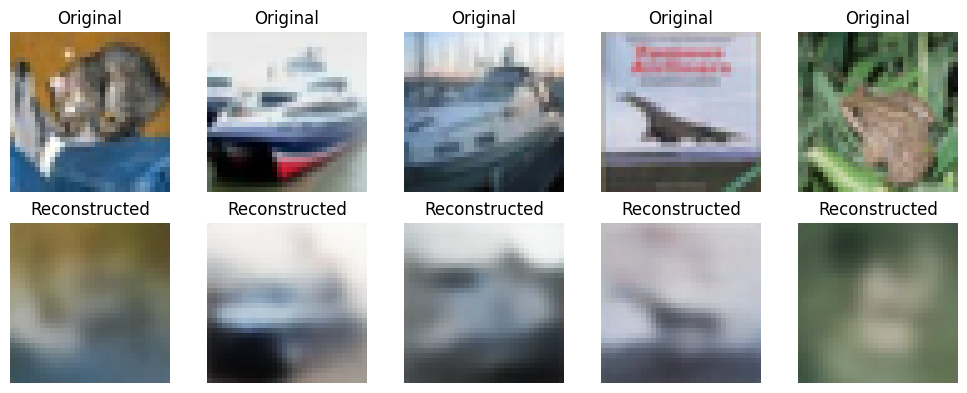

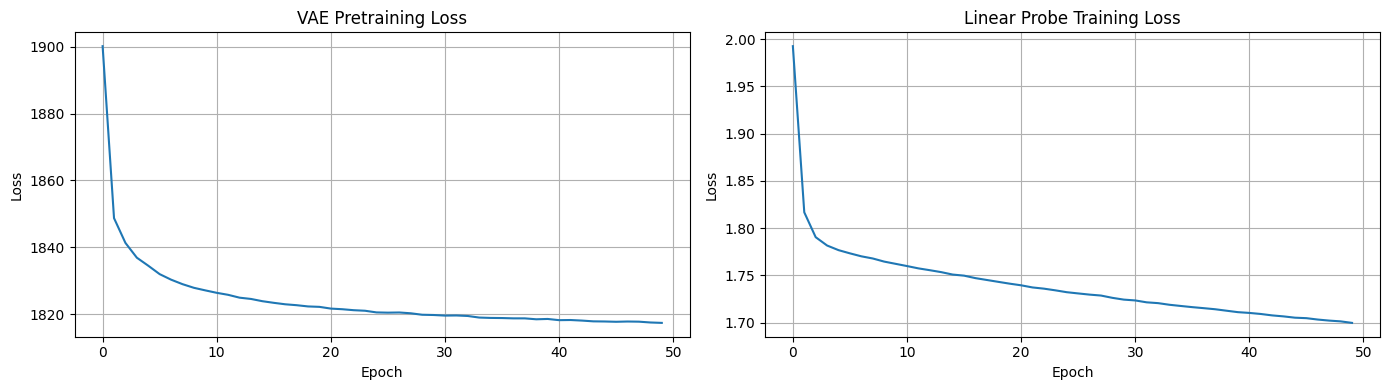

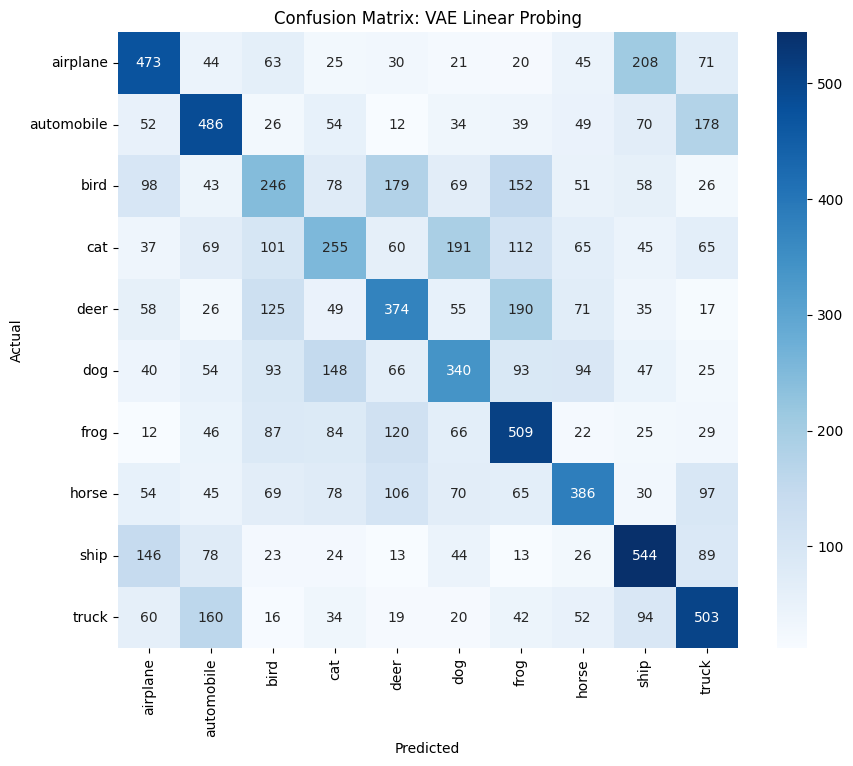

In [7]:
# ============================================
# Cell 7: 시각화
# ============================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. 복원 이미지
vae_model.eval()
with torch.no_grad():
    images, _ = next(iter(testloader))
    images = images.to(device)
    recon, _, _ = vae_model(images)
    recon = torch.clamp(recon, 0, 1)

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(np.transpose(images[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Original"); plt.axis('off')
    plt.subplot(2, 5, i + 6)
    plt.imshow(np.transpose(recon[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Reconstructed"); plt.axis('off')
plt.tight_layout(); plt.show()

# 2. Loss 곡선
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(pretrain_loss_history)
axes[0].set_title("VAE Pretraining Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(True)
axes[1].plot(probe_loss_history)
axes[1].set_title("Linear Probe Training Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].grid(True)
plt.tight_layout(); plt.show()

# 3. Confusion Matrix
all_preds, all_labels = [], []
probing_model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = probing_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
classes = trainset.classes
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix: VAE Linear Probing")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()